# Part 4.1 — Embeddings & Similarity
**Using sentence-transformers (all-MiniLM-L6-v2) to explore semantic similarity**

In [1]:
# Install required libraries
!pip install sentence-transformers -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Define 10 sentences across 3 topics

In [3]:
# 10 sentences: 4 Cricket, 3 Cooking, 3 Cybersecurity
sentences = [
    # Cricket (indices 0-3)
    "The batsman hit a brilliant century in the final over.",
    "India won the match by taking all ten wickets in the second innings.",
    "The fielder took an amazing catch near the boundary line.",
    "The spinner bowled a sharp googly that confused the batsman.",

    # Cooking (indices 4-6)
    "Always preheat the oven before baking a cake.",
    "Marinating chicken overnight makes it more tender and flavorful.",
    "A pinch of salt can greatly improve the taste of any dish.",

    # Cybersecurity (indices 7-9)
    "Using a strong password with special characters helps protect your account.",
    "Phishing attacks trick users into revealing their personal information.",
    "Installing antivirus software is a basic step in keeping your system secure."
]

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "CyberSec-1", "CyberSec-2", "CyberSec-3"
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i+1}. [{labels[i]}] {s}")

Total sentences: 10
1. [Cricket-1] The batsman hit a brilliant century in the final over.
2. [Cricket-2] India won the match by taking all ten wickets in the second innings.
3. [Cricket-3] The fielder took an amazing catch near the boundary line.
4. [Cricket-4] The spinner bowled a sharp googly that confused the batsman.
5. [Cooking-1] Always preheat the oven before baking a cake.
6. [Cooking-2] Marinating chicken overnight makes it more tender and flavorful.
7. [Cooking-3] A pinch of salt can greatly improve the taste of any dish.
8. [CyberSec-1] Using a strong password with special characters helps protect your account.
9. [CyberSec-2] Phishing attacks trick users into revealing their personal information.
10. [CyberSec-3] Installing antivirus software is a basic step in keeping your system secure.


## Step 2: Load the model and generate embeddings

In [4]:
# Load the sentence-transformers model
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded:", 'all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(sentences)
print(f"Embedding shape: {embeddings.shape}")
print("Each sentence is represented as a vector of 384 dimensions.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2
Embedding shape: (10, 384)
Each sentence is represented as a vector of 384 dimensions.


## Step 3: Compute 10x10 Cosine Similarity Matrix

In [5]:
# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print("Cosine Similarity Matrix (10x10):")
print(np.round(similarity_matrix, 2))

Cosine Similarity Matrix (10x10):
[[ 1.    0.6   0.4   0.51  0.01 -0.01 -0.01 -0.02 -0.01  0.01]
 [ 0.6   1.    0.25  0.4   0.02 -0.05  0.03 -0.04 -0.01  0.  ]
 [ 0.4   0.25  1.    0.36 -0.04 -0.    0.11 -0.02 -0.   -0.05]
 [ 0.51  0.4   0.36  1.   -0.03  0.02  0.13  0.    0.08 -0.07]
 [ 0.01  0.02 -0.04 -0.03  1.    0.08  0.12  0.04  0.12  0.11]
 [-0.01 -0.05 -0.    0.02  0.08  1.    0.35  0.11  0.    0.07]
 [-0.01  0.03  0.11  0.13  0.12  0.35  1.    0.12  0.06  0.01]
 [-0.02 -0.04 -0.02  0.    0.04  0.11  0.12  1.    0.32  0.26]
 [-0.01 -0.01 -0.    0.08  0.12  0.    0.06  0.32  1.    0.17]
 [ 0.01  0.   -0.05 -0.07  0.11  0.07  0.01  0.26  0.17  1.  ]]


## Step 4: Display Heatmap

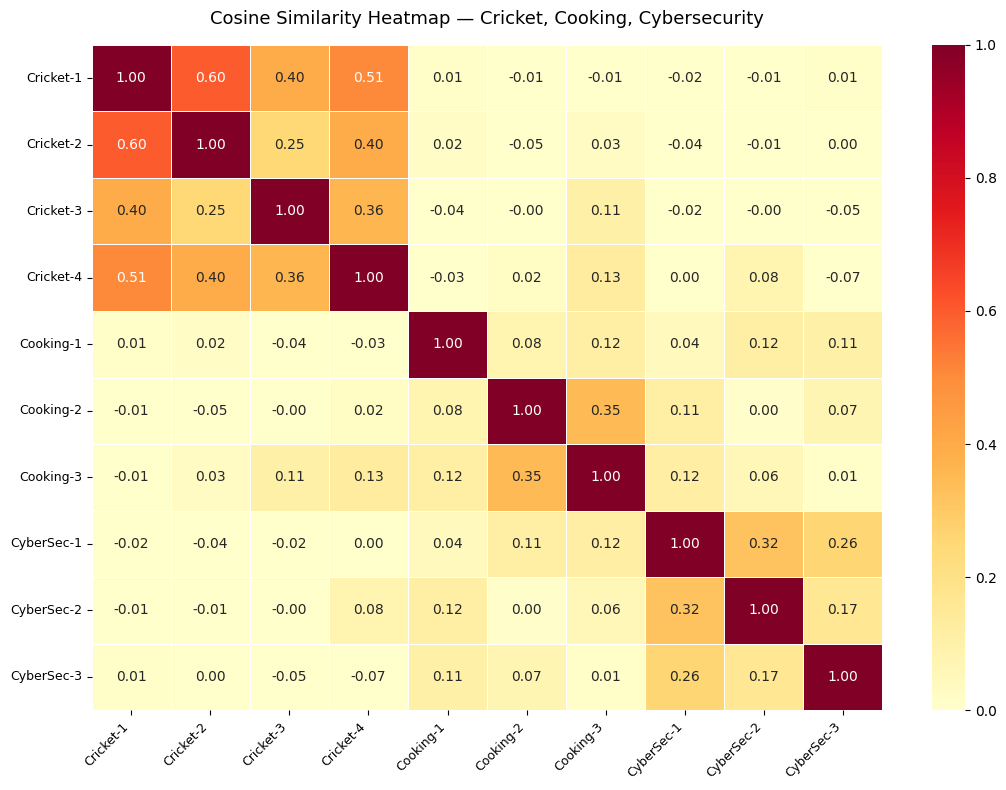

Observation: Sentences from the same topic show higher similarity scores,
while sentences from different topics have much lower scores.


In [6]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    similarity_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("Cosine Similarity Heatmap — Cricket, Cooking, Cybersecurity", fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("Observation: Sentences from the same topic show higher similarity scores,")
print("while sentences from different topics have much lower scores.")

## Step 5: Query — Find Top 2 Most Similar Sentences

In [7]:
# Query sentence
query = "The bowler took three wickets in one over"

# Generate embedding for the query
query_embedding = model.encode([query])

# Compute similarity between query and all sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar (sorted descending)
top2_indices = np.argsort(query_similarities)[::-1][:2]

print(f"Query: \"{query}\"")
print("\nTop 2 Most Similar Sentences:")
print("-" * 55)
for rank, idx in enumerate(top2_indices, 1):
    print(f"Rank {rank}: [{labels[idx]}]")
    print(f"  Sentence : {sentences[idx]}")
    print(f"  Similarity Score: {query_similarities[idx]:.4f}")
    print()

Query: "The bowler took three wickets in one over"

Top 2 Most Similar Sentences:
-------------------------------------------------------
Rank 1: [Cricket-2]
  Sentence : India won the match by taking all ten wickets in the second innings.
  Similarity Score: 0.6614

Rank 2: [Cricket-1]
  Sentence : The batsman hit a brilliant century in the final over.
  Similarity Score: 0.5835

